<a href="https://colab.research.google.com/github/kevintuluong-web/cs4375/blob/main/Decision_Tree_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Decision Tree Classification Model

We will use the built in Pima Indians Diabetes dataset. It is available as part of the SKlearn datasets. We have made it easily available for you.

In [2]:
import pandas as pd

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
# load dataset
pima = pd.read_csv("https://an-utd-python.s3.us-west-1.amazonaws.com/pima-indians-diabetes.csv", header=None, names=col_names)

In [3]:
pima.head()

,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
feature_cols = ['pregnant', 'insulin', 'bmi', 'age','glucose','bp','pedigree']
X = pima[feature_cols] # Features
y = pima.label # Target variable

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

In [6]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)

In [7]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, predictions)) # predictions contain predicted values (derived from probability with 0.5 threshold)
print('Predicted labels: ', predictions)
print('Accuracy: ', accuracy_score(y_test, predictions))


              precision    recall  f1-score   support

           0       0.71      0.79      0.75       146
           1       0.56      0.46      0.50        85

    accuracy                           0.67       231
   macro avg       0.64      0.62      0.63       231
weighted avg       0.66      0.67      0.66       231

Predicted labels:  [0 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0 1 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0
 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0
 0 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0 0 0 1 1 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0]
Accuracy:  0.6666666666666666


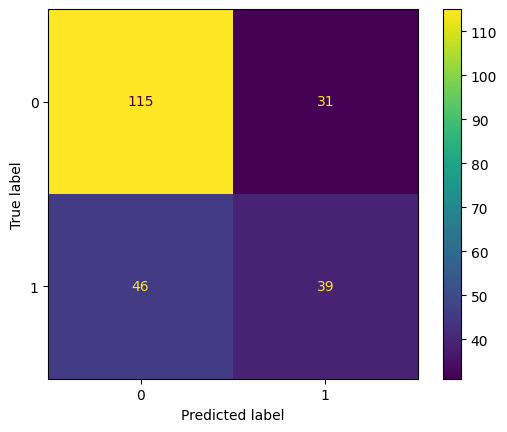

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()


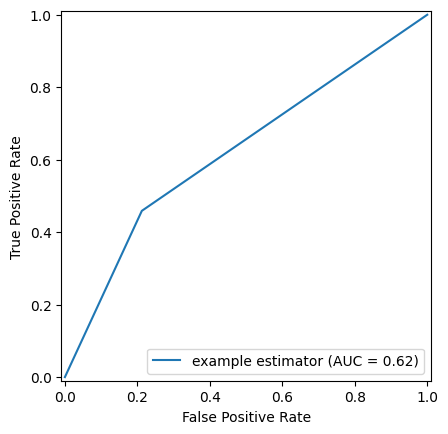

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

In [10]:
!pip install graphviz

In [11]:
X.columns

Index(['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree'], dtype='object')

In [12]:
classes = y.unique()

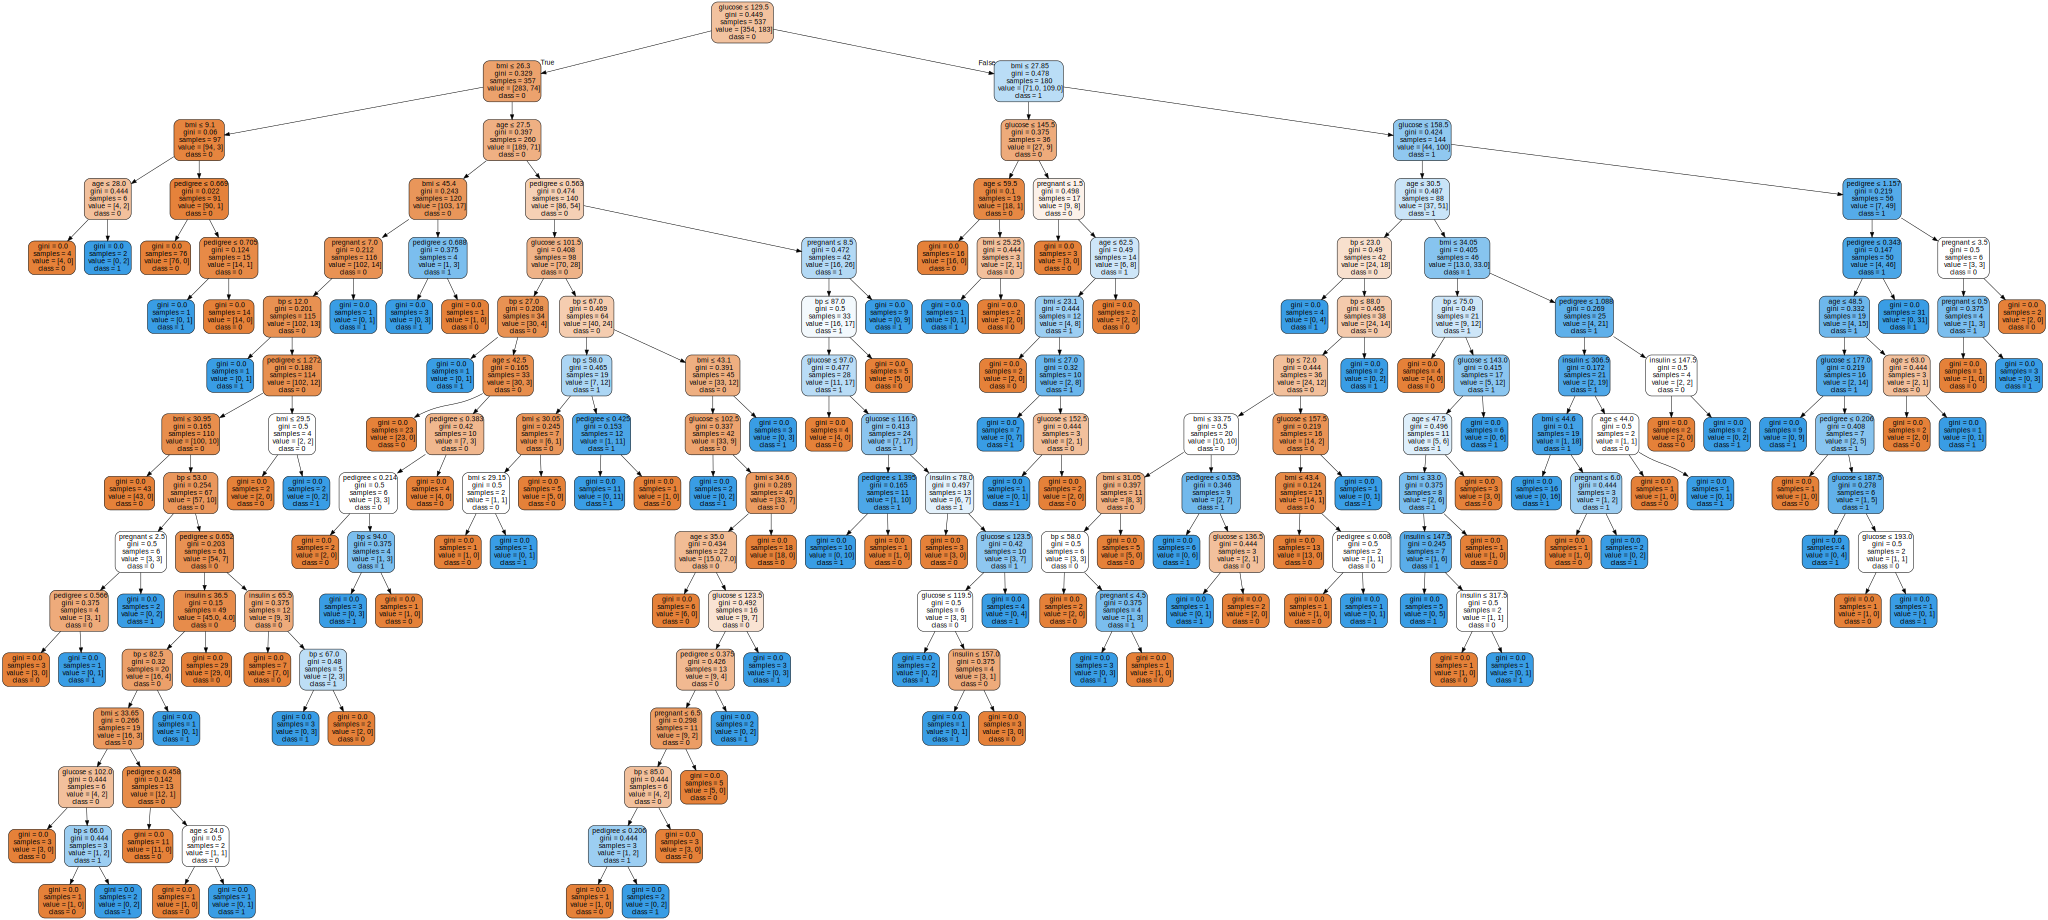

In [13]:
import graphviz
from sklearn import tree
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names = feature_cols,class_names=['0','1'],
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

# Excercise 1

Construct the following models on the same dataset:
- Bagging
- Random Forest
- Adaboost

Compare their performance and write a short paragraph on which one is the best. You are free to change the hyperparameters.


In [31]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

# Create Bagging Classifier Object
clf = BaggingClassifier(n_estimators=100)

# Train Bagging Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)

In [32]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, predictions)) # predictions contain predicted values (derived from probability with 0.5 threshold)
print('Predicted labels: ', predictions)
print('Accuracy: ', accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       146
           1       0.77      0.60      0.68        85

    accuracy                           0.79       231
   macro avg       0.78      0.75      0.76       231
weighted avg       0.79      0.79      0.78       231

Predicted labels:  [0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 1 1 1 1 0 0
 1 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0]
Accuracy:  0.7878787878787878


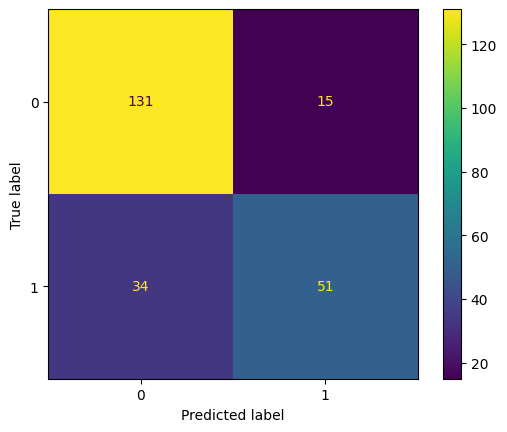

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

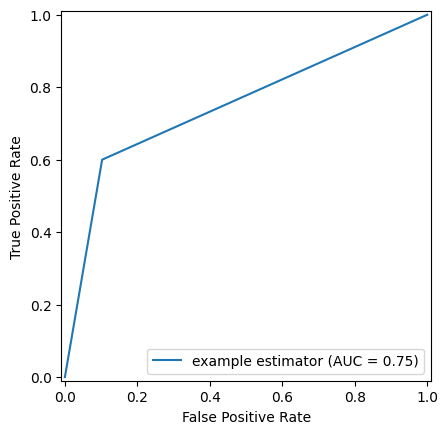

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

In [35]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

# Create RandomForest Classifier Object
clf = RandomForestClassifier(n_estimators=100)

# Train RandomForest Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)

In [36]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, predictions)) # predictions contain predicted values (derived from probability with 0.5 threshold)
print('Predicted labels: ', predictions)
print('Accuracy: ', accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.80      0.88      0.84       146
           1       0.75      0.61      0.68        85

    accuracy                           0.78       231
   macro avg       0.77      0.75      0.76       231
weighted avg       0.78      0.78      0.78       231

Predicted labels:  [0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 1 1 1 1 1 1 0
 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 1 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0]
Accuracy:  0.7835497835497836


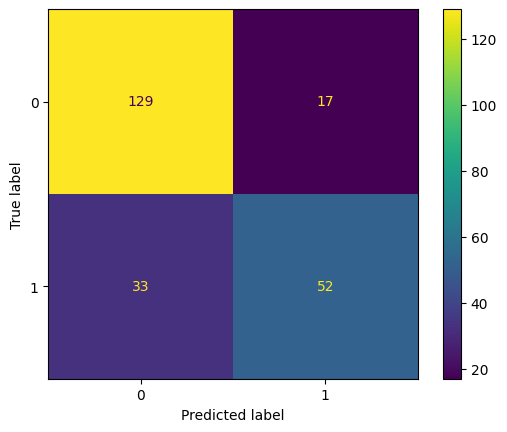

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

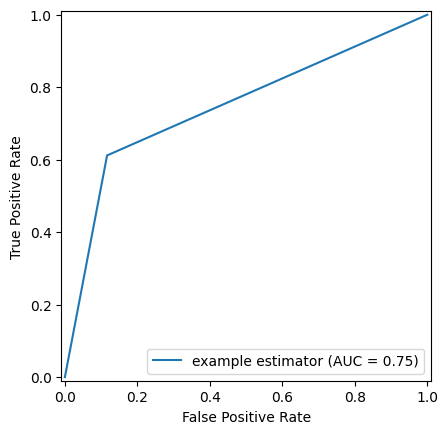

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

In [39]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier

# Create AdaBoost Classifier Object
clf = AdaBoostClassifier(n_estimators=100)

# Train AdaBoost Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)

In [40]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, predictions)) # predictions contain predicted values (derived from probability with 0.5 threshold)
print('Predicted labels: ', predictions)
print('Accuracy: ', accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.78      0.86      0.82       146
           1       0.71      0.59      0.65        85

    accuracy                           0.76       231
   macro avg       0.75      0.73      0.73       231
weighted avg       0.76      0.76      0.76       231

Predicted labels:  [0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 1 0
 1 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 1 0 0 1 1 0 0 0
 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 1 1 0 0 1 0 1 0 0 0 1 1 0 1 0
 0 0 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 1 0]
Accuracy:  0.7619047619047619


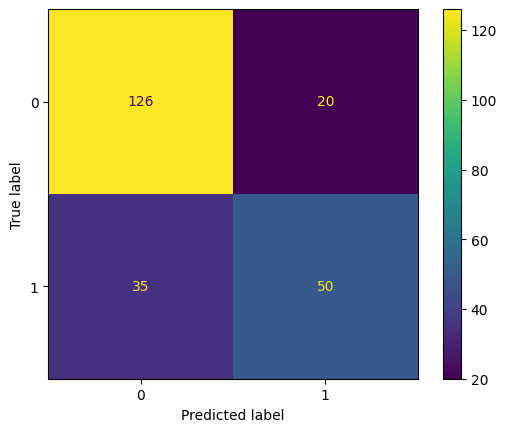

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

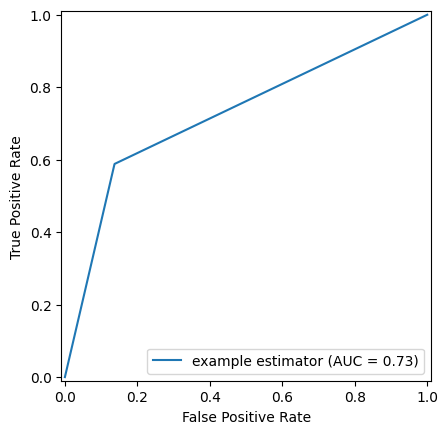

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, predictions)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='example estimator')
display.plot()
plt.show()

In [94]:
print("""After running all three classifiers, I found that Bagging performed the best overall with the highest accuracy of 78.79%, a weighted F1-score of 0.78, and
a macro score of 0.76. For Random Forest, it was very close to Bagging with amn accuracy of 78.35%, the same weighted F1-score of 0.78, and the same macro score
of 0.76. This indicates that the additional feature randomization in Random Forest provided no significant advantage over standard Bagging on the given dataset.
For AdaBoost, it was last with an accuracy of 76.19%, a lower weighted F1-score of 0.76, and a lower macro score of 0.73. This suggests that the sequential
boosting strategy is less effective here, which could be caused by the noise in the dataset. I also noticed that all three models struggled the most with class 1
recall compared to class 0. This may point to a class imbalance issue in the dataset. Overall, the differences between each classifier weren't large, I found that
Bagging Classifier is the most suitable model for this dataset. """)

After running all three classifiers, I found that Bagging performed the best overall with the highest accuracy of 78.79%, a weighted F1-score of 0.78, and 
a macro score of 0.76. For Random Forest, it was very close to Bagging with amn accuracy of 78.35%, the same weighted F1-score of 0.78, and the same macro score 
of 0.76. This indicates that the additional feature randomization in Random Forest provided no significant advantage over standard Bagging on the given dataset.
For AdaBoost, it was last with an accuracy of 76.19%, a lower weighted F1-score of 0.76, and a lower macro score of 0.73. This suggests that the sequential 
boosting strategy is less effective here, which could be caused by the noise in the dataset. I also noticed that all three models struggled the most with class 1
recall compared to class 0. This may point to a class imbalance issue in the dataset. Overall, the differences between each classifier weren't large, I found that
Bagging Classifier is the most suitable

### Application on Cuisines Dataset

In [51]:
import pandas as pd
cuisines_df = pd.read_csv("https://raw.githubusercontent.com/a-nagar/datasets/refs/heads/main/asian_cuisines.csv")
cuisines_df.head()

,cuisine,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,indian,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,indian,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [52]:
cuisines_label_df = cuisines_df['cuisine']
cuisines_label_df.head()

,cuisine
0,indian
1,indian
2,indian
3,indian
4,indian


In [53]:
cuisines_label_df.value_counts()

,count
cuisine,
indian,799
thai,799
chinese,799
japanese,799
korean,799


In [54]:
cuisine_labels_distinct = cuisines_label_df.unique()

In [55]:
cuisine_labels_distinct

array(['indian', 'thai', 'chinese', 'japanese', 'korean'], dtype=object)

In [56]:
cuisines_feature_df = cuisines_df.drop(['cuisine'], axis=1)
cuisines_feature_df.head()

,almond,angelica,anise,anise_seed,apple,apple_brandy,apricot,armagnac,artemisia,artichoke,...,whiskey,white_bread,white_wine,whole_grain_wheat_flour,wine,wood,yam,yeast,yogurt,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [57]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score,precision_score,confusion_matrix,classification_report, precision_recall_curve
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(cuisines_feature_df, cuisines_label_df, test_size=0.3)

In [58]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(max_depth=10)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)
predicted_probas = clf.predict_proba(X_test)

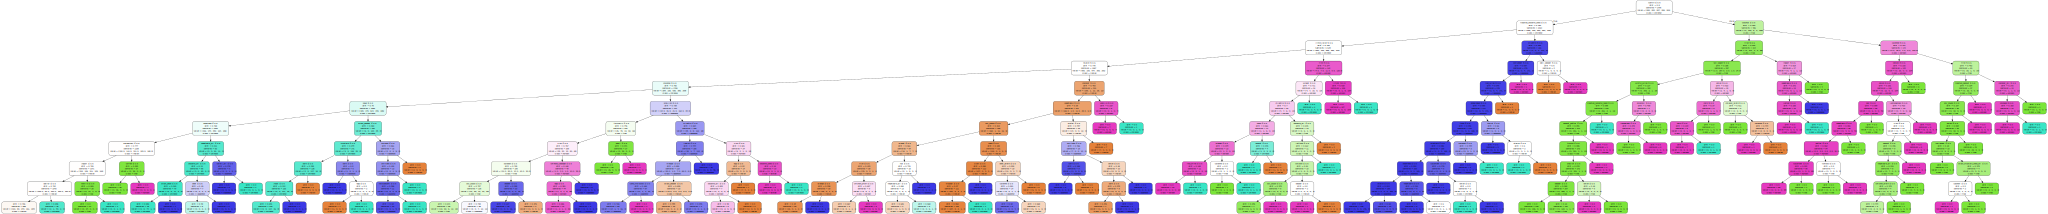

In [59]:
import graphviz
dot_data = tree.export_graphviz(clf, out_file=None,
                     feature_names=cuisines_feature_df.columns,
                     class_names=cuisine_labels_distinct,
                     filled=True, rounded=True,
                     special_characters=True)
graph = graphviz.Source(dot_data)
graph

In [86]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred))
print('Accuracy: ', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

     chinese       0.55      0.64      0.60       239
      indian       0.84      0.77      0.80       247
    japanese       0.47      0.75      0.58       232
      korean       0.86      0.56      0.68       243
        thai       0.79      0.54      0.64       238

    accuracy                           0.65      1199
   macro avg       0.70      0.65      0.66      1199
weighted avg       0.70      0.65      0.66      1199

Accuracy:  0.6522101751459549


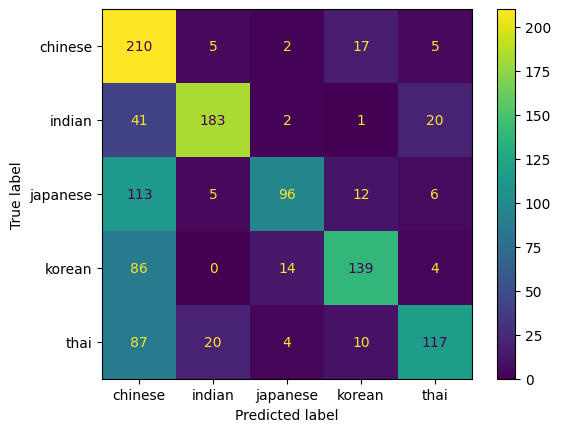

In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

# Exercise 2

The accuracy for this dataset is quite low. Can you try any other method that increases the accuracy. You can try either Random Forest or Adaboost. What do you notice?

In [87]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Create RandomForest classifer object
clf = RandomForestClassifier(max_depth=10)

# Train RandomForest Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)
predicted_probas = clf.predict_proba(X_test)

In [88]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred))
print('Accuracy: ', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

     chinese       0.74      0.66      0.70       239
      indian       0.90      0.84      0.87       247
    japanese       0.55      0.84      0.67       232
      korean       0.86      0.76      0.81       243
        thai       0.89      0.68      0.77       238

    accuracy                           0.76      1199
   macro avg       0.79      0.76      0.76      1199
weighted avg       0.79      0.76      0.76      1199

Accuracy:  0.7581317764804003


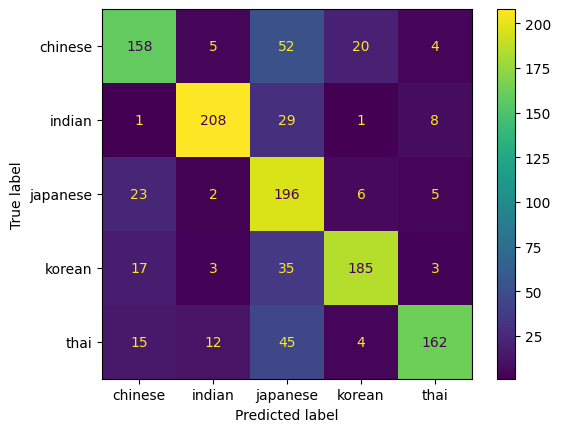

In [89]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

In [90]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Create AdaBoost classifer object
clf = AdaBoostClassifier(n_estimators=100)

# Train AdaBoost Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
predictions = clf.predict(X_test)
predicted_probas = clf.predict_proba(X_test)

In [91]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = clf.predict(X_test)
y_probs = clf.predict_proba(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test,y_pred))
print('Accuracy: ', accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

     chinese       0.55      0.64      0.60       239
      indian       0.84      0.77      0.80       247
    japanese       0.47      0.75      0.58       232
      korean       0.86      0.56      0.68       243
        thai       0.79      0.54      0.64       238

    accuracy                           0.65      1199
   macro avg       0.70      0.65      0.66      1199
weighted avg       0.70      0.65      0.66      1199

Accuracy:  0.6522101751459549


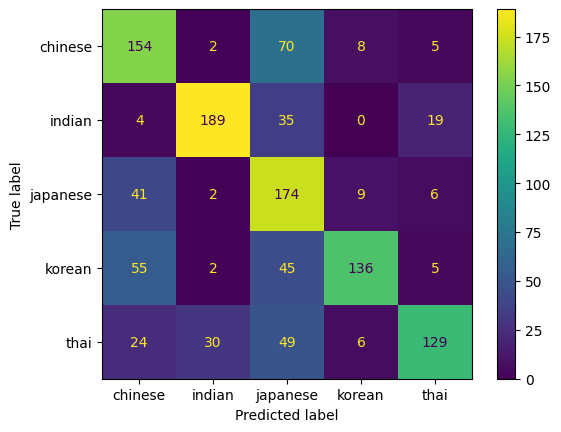

In [92]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

In [95]:
print("""After running both RandomForest and AdaBoost Classifier, I found out that using Random Forest improved the accuracy significantly over the Decision Tree baseline.
Decision Tree had an accuracy of 65.22%, and the implementation of Random Forest gave an accuracy of 75.81%. I would assume this is correct because Random Forest
builds a bunch of trees and average out the results, which reduces overfitting. For AdaBoost Classifier, it showed no improvement at all because the accuracy of
AdaBoost was 65.22%, which is the same as the Decision Tree Classifier. This means that sequentially boosting the weak learners doesn't help much for this dataset.
Overall, I found that the Random Forest Classifier improves the accuracy of this data compared to AdaBoost Classifier. """)

After running both RandomForest and AdaBoost Classifier, I found out that using Random Forest improved the accuracy significantly over the Decision Tree baseline.
Decision Tree had an accuracy of 65.22%, and the implementation of Random Forest gave an accuracy of 75.81%. I would assume this is correct because Random Forest
builds a bunch of trees and average out the results, which reduces overfitting. For AdaBoost Classifier, it showed no improvement at all because the accuracy of
AdaBoost was 65.22%, which is the same as the Decision Tree Classifier. This means that sequentially boosting the weak learners doesn't help much for this dataset.
Overall, I found that the Random Forest Classifier improves the accuracy of this data compared to AdaBoost Classifier. 


# Parameter Grid Builder for Parameter Tuning

In [96]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

dt_pipe = Pipeline([('mms', MinMaxScaler()),
                     ('dt', DecisionTreeClassifier())])
params = [{'dt__max_depth': [3, 5, 7, 9],
         'dt__min_samples_leaf': [2, 3, 5]}]

gs_dt = GridSearchCV(dt_pipe,
                      param_grid=params,
                      scoring='accuracy',
                      cv=5)
gs_dt.fit(cuisines_feature_df, cuisines_label_df)
print(gs_dt.best_params_)
# find best model score
print(gs_dt.score(cuisines_feature_df, cuisines_label_df))


{'dt__max_depth': 9, 'dt__min_samples_leaf': 3}
0.6475594493116396


In [97]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier()

params = {'max_depth': [5, 7, 9],
          'n_estimators': [50, 100, 200],
          'max_features': ['sqrt', 'log2']
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

{'max_depth': 9, 'max_features': 'log2', 'n_estimators': 100}
0.7944931163954944


# Exercise 3

Try other combination of hyperparameters for Random Forest and AdaBoost models and check how good of an accuracy you can obtain.

In [101]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier()

params = {'max_depth': [10, 12, 15],
          'n_estimators': [100, 200, 300],
          'max_features': ['sqrt', 'log2']
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

{'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200}
0.8653316645807259


In [103]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

rf = RandomForestClassifier()

params = {'max_depth': [15, 20, None],
          'n_estimators': [200, 300, 500],
          'max_features': ['sqrt', 'log2'],
          'min_samples_split': [2, 5, 10]
          }

grid = GridSearchCV(rf, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 500}
0.9654568210262828


In [104]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

ab = AdaBoostClassifier()

params = {'n_estimators': [50, 200],
          'learning_rate': [0.5, 1.5, 2.0]
          }

grid = GridSearchCV(ab, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

{'learning_rate': 1.5, 'n_estimators': 200}
0.7319148936170212


In [105]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

ab = AdaBoostClassifier()

params = {'n_estimators': [200, 300, 500],
          'learning_rate': [1.0, 1.5, 2.0]
          }

grid = GridSearchCV(ab, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

{'learning_rate': 1.5, 'n_estimators': 500}
0.7384230287859824


In [106]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

ab = AdaBoostClassifier()

params = {'n_estimators': [200, 300, 500],
          'learning_rate': [1.0, 1.5, 2.0],
          'estimator': [DecisionTreeClassifier(max_depth=2), DecisionTreeClassifier(max_depth=3)]
          }

grid = GridSearchCV(ab, params, cv=10, scoring='accuracy', return_train_score=False)
grid.fit(cuisines_feature_df, cuisines_label_df)

print(grid.best_params_)
# find best model score
print(grid.score(cuisines_feature_df, cuisines_label_df))

{'estimator': DecisionTreeClassifier(max_depth=3), 'learning_rate': 1.0, 'n_estimators': 500}
0.8202753441802253


In [107]:
print("""After running and messing with the hyperparameters of RandomForest and AdaBoost a couple of times, I was able conclude the highest accuracy I could get for
RandomForest was 96.55% without waiting a long period of time. As for AdaBoost, I was able to get the highest accuracy of 82.03% without waiting a long period
of time. """)

After running and messing with the hyperparameters of RandomForest and AdaBoost a couple of times, I was able conclude the highest accuracy I could get for
RandomForest was 96.55% without waiting a long period of time. As for AdaBoost, I was able to get the highest accuracy of 82.03% without waiting a long period
of time. 
